In [1]:
import numpy as np
import matplotlib.pyplot as plt


def read_latency_data(file_path, ignore):
    with open(file_path, "r") as file:
        latencies = [int(line.strip()) for line in file if line.strip().isdigit()]
    n_ignore = int(len(latencies) * ignore)
    latencies = latencies[n_ignore:]
    return latencies


def get_pctl(data, pctl):
    data = np.sort(data)
    tail = np.percentile(data, pctl).astype(int)
    return tail

In [6]:
rps_values = [50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300, 325, 350, 375, 400, 425, 450]

data = {
    "rps": [],
    "fcfs": [],
    "masa": [],
    "relative": [],
}

for rps in rps_values:
    data["rps"].append(rps)

    file_path = f"r{rps}-fcfs.csv"
    tail = get_pctl(read_latency_data(file_path, ignore=0.2), 99)
    data["fcfs"].append(tail)

    file_path = f"r{rps}-masa.csv"
    tail = get_pctl(read_latency_data(file_path, ignore=0.2), 99)
    data["masa"].append(tail)

    data["relative"].append((data["fcfs"][-1] - data["masa"][-1]) / data["fcfs"][-1] * 100)

raw = data
print(raw)

{'rps': [50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300, 325, 350, 375, 400, 425, 450], 'fcfs': [33592, 33671, 33742, 33871, 34089, 34377, 34595, 34850, 35242, 35824, 36638, 37602, 39238, 41726, 45246, 50853, 63383], 'masa': [33535, 33633, 33659, 33687, 33853, 33984, 34068, 34180, 34253, 34407, 34719, 35215, 36356, 38567, 42419, 48487, 61752], 'relative': [0.16968325791855204, 0.11285676101095898, 0.24598423329974511, 0.5432375778689735, 0.6923054357710698, 1.1432062134566716, 1.5233415233415233, 1.9225251076040173, 2.8063106520628796, 3.9554488610987044, 5.2377313172116375, 6.348066592202542, 7.3449207400988845, 7.570819153525379, 6.248066127392477, 4.6526261970778515, 2.573245191928435]}


{'rps': [50, 100, 150, 200, 250, 300, 350, 400, 450], 'fcfs': [33.592, 33.742, 34.089, 34.595, 35.242, 36.638, 39.238, 45.246, 63.383], 'masa': [33.535, 33.659, 33.853, 34.068, 34.253, 34.719, 36.356, 42.419, 61.752], 'diff': [-0.05700000000000216, -0.08299999999999841, -0.2359999999999971, -0.527000000000001, -0.9889999999999972, -1.918999999999997, -2.881999999999998, -2.8270000000000053, -1.6310000000000002]}


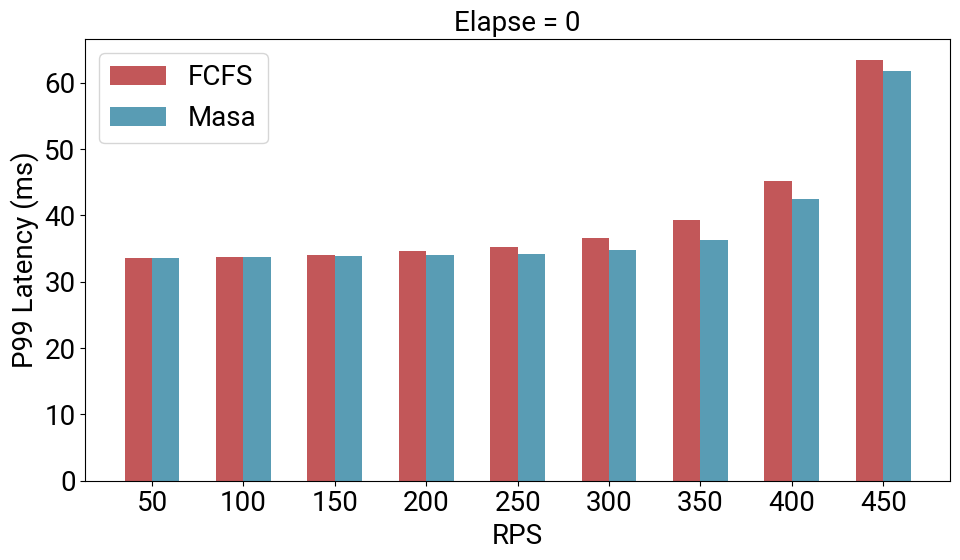

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "Roboto"

plt.rcParams.update(
    {
        "font.size": 20,  # Sets the base default font size
        "axes.labelsize": 20,  # Font size for x and y labels
        "axes.titlesize": 20,  # Font size for plot title
        "xtick.labelsize": 20,  # Font size for x-axis tick labels
        "ytick.labelsize": 20,  # Font size for y-axis tick labels
        "legend.fontsize": 20,  # Font size for legend
    }
)

data = raw

for key in ["fcfs", "masa"]:
    data[key] = [x / 1e3 for x in data[key]]

data["diff"] = []
for i in range(len(data["rps"])):
    data["diff"].append(data["masa"][i] - data["fcfs"][i])

print(data)

# print(data)

# Setting the positions of the bars on the x-axis
x = np.arange(len(data["rps"]))  # the label locations
width = 0.3  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(
    x - width / 2,
    data["fcfs"],
    width,
    label="FCFS",
    color="#C25759",
)
rects2 = ax.bar(
    x + width / 2,
    data["masa"],
    width,
    label="Masa",
    color="#599CB4",
)

# Annotate the bars with the diff
# for i, diff in enumerate(data["diff"]):
#     if diff > 0:
#         text = f"+{diff:.1f}"
#     else:
#         text = f"{diff:.1f}"
#     ax.text(
#         x[i] + width / 2,
#         max(data["fcfs"][i], data["masa"][i]) + 0.2,
#         text,
#         ha="center",
#         va="bottom",
#         color="black",
#         fontsize=18,
#     )

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_title("Elapse = 0")
ax.set_xlabel("RPS")
ax.set_ylabel("P99 Latency (ms)")
# ax.set_ylim(0, 40)
ax.set_xticks(x)
ax.set_xticklabels(data["rps"])
ax.legend()

fig.tight_layout()
plt.savefig("ex0.pdf")
plt.show()